## Assignment 7: K-Means Clustering on Wine Quality Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 1. Load the dataset
Downloaded from: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

In [6]:
df = pd.read_csv('winequality-red.csv', sep=';')

### 2. Display first 10 rows and identify variables

In [17]:
print("First 10 rows:")
print(df.head(10))
print("\nVariables:")
print(df.columns.tolist())

First 10 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            7.5              0.50         0.36             6.1      0.071   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.997

### 3. Check for missing values

In [18]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
cluster                 0
dtype: int64


### 4. Separate features and quality variable

In [19]:
X = df.drop('quality', axis=1)
y = df['quality']
print("Features shape:", X.shape)
print("Quality shape:", y.shape)

Features shape: (1599, 12)
Quality shape: (1599,)


**Why quality is not used in clustering:**

Clustering is unsupervised learning. It groups data based on similarity without using labels.

### 5. Feature scaling

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Why scaling is necessary:**

K-Means uses distance calculations. Features with larger values dominate. Scaling makes all features equal.

### 6. Apply K-Means clustering

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
print("Cluster labels:")
print(clusters)

Cluster labels:
[0 2 0 ... 0 0 0]


### 7. Elbow Method

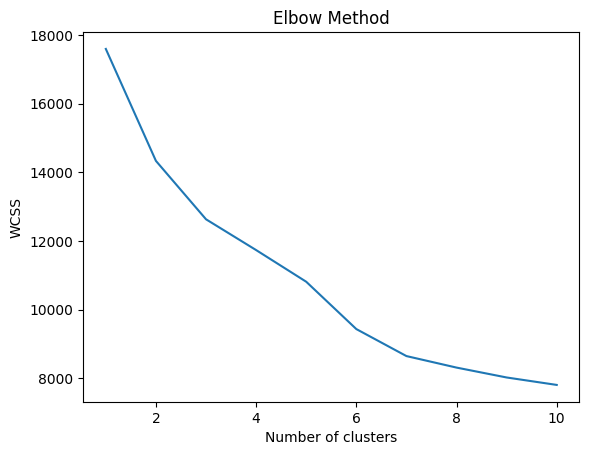

In [21]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Optimal number of clusters: 3

### 8. Visualize clusters

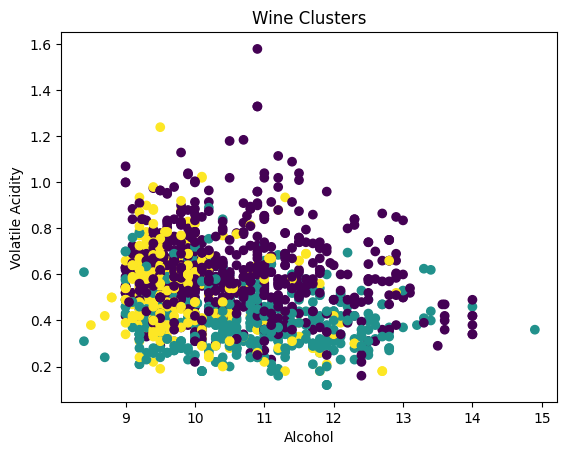

In [13]:
plt.scatter(X['alcohol'], X['volatile acidity'], c=clusters)
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('Wine Clusters')
plt.show()

### 9. Analyze clusters

In [14]:
df['cluster'] = clusters
print("Cluster characteristics:")
print(df.groupby('cluster').mean())

Cluster characteristics:
         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.078553            13.507618             34.894737  0.995896   
1         0.100460            10.888446             30.627490  0.997574   
2         0.087235            27.108000             89.954667  0.997276   

               pH  sulphates    alcohol   quality  
cluster                                            
0        3.405762   0.609224  10.494044  5.552632  
1        3.195040   0.752131  10.724037  5.960159  
2        3.284267   0.626

**Cluster differences:**

Each cluster has different average values for alcohol, acidity, sulfates, etc. Wines are grouped by similar chemical properties.

### 10. Compare with actual quality

In [23]:
print("Average quality per cluster:")
print(df.groupby('cluster')['quality'].mean())
print("\nQuality distribution per cluster:")
print(pd.crosstab(df['cluster'], df['quality']))

Average quality per cluster:
cluster
0    5.552632
1    5.960159
2    5.362667
Name: quality, dtype: float64

Quality distribution per cluster:
quality  3   4    5    6    7   8
cluster                          
0        7  38  303  304   63   7
1        3   9  135  223  122  10
2        0   6  243  111   14   1


**Discussion:**

Clustering does not perfectly match quality scores. Clusters group wines by chemical similarity, not quality rating. Quality is subjective while clustering is based on measurable features.